# Phân tích và Dự đoán Tỷ lệ Tội phạm Bạo lực tại Hoa Kỳ
### Communities and Crime Unnormalized Dataset - UCI Machine Learning Repository

---

**Mục tiêu nghiên cứu:** Phân tích tỷ lệ tội phạm bạo lực trên 100.000 dân (`violentPerPop`) và xây dựng mô hình dự báo nhằm định lượng rủi ro, xác định trước các điểm nóng tội phạm dựa trên các đặc điểm kinh tế – xã hội, môi trường và nhân khẩu học. Qua đó hỗ trợ công tác quy hoạch đô thị và triển khai lực lượng an ninh hiệu quả.

**Cấu trúc notebook:**

| # | Giai đoạn | Mô tả |
|---|-----------|--------|
| 1 | Data Understanding | Tải dữ liệu, khám phá cấu trúc và thống kê tổng quan |
| 2 | Data Cleaning | Xử lý giá trị khuyết, chuẩn hóa kiểu dữ liệu |
| 3 | Exploratory Data Analysis | Bản đồ nhiệt địa lý, phân tích tương quan, trực quan hóa |
| 4 | Outlier Handling | Phân tích phân phối, biến đổi Log, Winsorization |
| 5 | Feature Engineering | Lựa chọn và chuẩn bị đặc trưng cho mô hình |
| 6 | Modelling | Huấn luyện và so sánh các mô hình hồi quy |
| 7 | Evaluation | Đánh giá hiệu suất, phân tích phần dư |
| 8 | Conclusion | Tổng kết kết quả và kiến nghị |

---
## Import thư viện

In [18]:
# --- Xử lý dữ liệu ---
import pandas as pd
import numpy as np

# --- Trực quan dữ liệu ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# --- Thống kê ---
import scipy.stats as stats

# --- Machine Learning ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- Tải dữ liệu ---
from ucimlrepo import fetch_ucirepo

# --- Hiển thị ---
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('Import thư viện thành công!')

Import thư viện thành công!


---
# PHẦN 1: Khám phá dữ liệu

Bộ dữ liệu **Communities and Crime Unnormalized** từ UCI Machine Learning Repository chứa thông tin của 2.215 cộng đồng trên toàn nước Mỹ với 147 biến, bao gồm:
- Dữ liệu nhân khẩu học (dân số, cơ cấu tuổi, sắc tộc)
- Dữ liệu kinh tế – xã hội (thu nhập, tỷ lệ nghèo, thất nghiệp)
- Dữ liệu về cấu trúc gia đình và nhà ở
- Thống kê tội phạm (biến mục tiêu: `violentPerPop`)

### 1.1. Tải dữ liệu từ UCI Repository

In [19]:
# Tải bộ dữ liệu Communities and Crime Unnormalized (ID = 211)
communities_and_crime_unnormalized = fetch_ucirepo(id=211)
df_raw = communities_and_crime_unnormalized.data.original

print(f'Kích thước dữ liệu gốc: {df_raw.shape[0]} dòng × {df_raw.shape[1]} cột')
df_raw.head()

Kích thước dữ liệu gốc: 2215 dòng × 147 cột


,communityname,State,countyCode,communityCode,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,39.0,5320.0,1,11980,3.10,1.37,91.78,6.50,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,45.0,47616.0,1,23123,2.82,0.80,95.57,3.44,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,NaN,NaN,1,29344,2.43,0.74,94.33,3.43,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,35.0,29443.0,1,16656,2.40,1.70,97.35,0.50,...,225.0,1301.78,716.0,4142.56,47.0,271.93,NaN,NaN,306.64,NaN
4,Bemidjicity,MN,7.0,5068.0,1,11245,2.76,0.53,89.16,1.17,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,NaN,9988.79


### 1.2. Khám phá cấu trúc dữ liệu

In [20]:
# Thông tin tổng quan về DataFrame
print('═' * 60)
print('THÔNG TIN CẤU TRÚC DỮ LIỆU')
print('═' * 60)
print(f'Số dòng (mẫu):  {df_raw.shape[0]}')
print(f'Số cột (biến):  {df_raw.shape[1]}')
print(f'\nCác kiểu dữ liệu:')
print(df_raw.dtypes.value_counts())
display(df_raw.head())

════════════════════════════════════════════════════════════
THÔNG TIN CẤU TRÚC DỮ LIỆU
════════════════════════════════════════════════════════════
Số dòng (mẫu):  2215
Số cột (biến):  147

Các kiểu dữ liệu:
float64    116
int64       29
object       2
Name: count, dtype: int64


,communityname,State,countyCode,communityCode,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,39.0,5320.0,1,11980,3.10,1.37,91.78,6.50,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,45.0,47616.0,1,23123,2.82,0.80,95.57,3.44,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,NaN,NaN,1,29344,2.43,0.74,94.33,3.43,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,35.0,29443.0,1,16656,2.40,1.70,97.35,0.50,...,225.0,1301.78,716.0,4142.56,47.0,271.93,NaN,NaN,306.64,NaN
4,Bemidjicity,MN,7.0,5068.0,1,11245,2.76,0.53,89.16,1.17,...,91.0,728.93,1060.0,8490.87,91.0,728.93,5.0,40.05,NaN,9988.79


In [21]:
# Thống kê mô tả
df_raw.describe()

,countyCode,communityCode,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,pctHisp,pct12-21,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
count,994.000000,991.000000,2215.000000,2.215000e+03,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,2215.000000,...,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2124.000000,2124.000000,1994.000000,2118.000000
mean,65.587525,45209.251261,5.494357,5.311798e+04,2.707327,9.335102,83.979819,2.670203,7.950176,14.445837,...,761.236890,1033.430203,2137.629295,3372.979150,516.692586,473.965628,30.907721,32.153682,589.078922,4908.241804
std,117.831399,25425.861573,2.872924,2.046203e+05,0.334120,14.247156,16.419080,4.473843,14.589832,4.518623,...,3111.702756,763.354442,7600.573464,1901.316145,3258.164244,504.666026,180.125248,39.240900,614.784518,2739.708901
min,1.000000,70.000000,1.000000,1.000500e+04,1.600000,0.000000,2.680000,0.030000,0.120000,4.580000,...,2.000000,16.920000,10.000000,77.860000,1.000000,6.550000,0.000000,0.000000,0.000000,116.790000
25%,11.000000,22887.000000,3.000000,1.436600e+04,2.500000,0.860000,76.320000,0.620000,0.930000,12.250000,...,95.000000,511.690000,392.000000,2040.080000,30.000000,156.952500,1.000000,7.670000,161.700000,2918.070000
50%,27.000000,46925.000000,5.000000,2.279200e+04,2.660000,2.870000,90.350000,1.230000,2.180000,13.620000,...,205.000000,822.715000,747.000000,3079.510000,75.000000,302.355000,5.000000,21.080000,374.060000,4425.450000
75%,80.500000,65805.000000,8.000000,4.302400e+04,2.850000,11.145000,96.225000,2.670000,7.810000,15.360000,...,508.000000,1350.232500,1675.000000,4335.410000,232.500000,589.775000,16.000000,42.852500,794.400000,6229.280000
max,840.000000,94597.000000,10.000000,7.322564e+06,5.280000,96.670000,99.630000,57.460000,95.290000,54.400000,...,99207.000000,11881.020000,235132.000000,25910.550000,112464.000000,4968.590000,5119.000000,436.370000,4877.060000,27119.760000


---
# PHẦN 2: DATA CLEANING - Làm sạch dữ liệu

Quá trình làm sạch dữ liệu bao gồm:
1. Thay thế ký tự `'?'` bằng `NaN`
2. Chuyển đổi kiểu dữ liệu sang dạng số
3. Loại bỏ các cột có tỷ lệ giá trị khuyết > 50%
4. Xóa các hàng thiếu biến mục tiêu (`violentPerPop`)
5. Điền giá trị trung vị (median) cho các biến độc lập còn thiếu

### 2.1. Xử lý ký tự đặc biệt và chuyển đổi kiểu dữ liệu

In [22]:
# Thay thế ký tự '?' bằng NaN
df = df_raw.replace('?', np.nan)

# Chuyển đổi các cột số (từ cột thứ 6 trở đi) sang kiểu numeric
cols_to_convert = df.columns[5:]
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Đã chuyển đổi {len(cols_to_convert)} cột sang kiểu số.')
print(f'Tổng giá trị khuyết ban đầu: {df.isnull().sum().sum():,}')

Đã chuyển đổi 142 cột sang kiểu số.
Tổng giá trị khuyết ban đầu: 44,592


### 2.2. Xử lý giá trị khuyết (Missing Values)

In [23]:
# --- 1. Loại bỏ các cột có tỷ lệ khuyết > 50% ---
missing_percent = df.isnull().mean() * 100
cols_missing_over_50 = missing_percent[missing_percent > 50].index
df = df.drop(columns=cols_missing_over_50)
print(f'Đã loại bỏ {len(cols_missing_over_50)} cột do thiếu > 50% dữ liệu.')

# --- 2. Xóa hàng thiếu biến mục tiêu ---
rows_before = len(df)
df = df.dropna(subset=['violentPerPop'])
print(f'Đã xóa {rows_before - len(df)} hàng do thiếu giá trị biến mục tiêu.')

# --- 3. Điền Median cho các biến số còn lại ---
feature_cols = df.select_dtypes(include=[np.number]).columns.drop('violentPerPop')
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

print(f'\n Hoàn tất làm sạch dữ liệu!')
print(f' Kích thước sau khi làm sạch: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f' Giá trị khuyết còn lại: {df.isnull().sum().sum()}')

Đã loại bỏ 24 cột do thiếu > 50% dữ liệu.
Đã xóa 221 hàng do thiếu giá trị biến mục tiêu.

 Hoàn tất làm sạch dữ liệu!
 Kích thước sau khi làm sạch: 1994 dòng × 123 cột
 Giá trị khuyết còn lại: 0


In [24]:
# Các kiểu dữ liệu sau khi làm sạch
display(df.head())
print(f'\nCác kiểu dữ liệu sau khi làm sạch:')
print(df.dtypes.value_counts())

,communityname,State,fold,pop,perHoush,pctBlack,pctWhite,pctAsian,pctHisp,pct12-21,...,burglaries,burglPerPop,larcenies,larcPerPop,autoTheft,autoTheftPerPop,arsons,arsonsPerPop,violentPerPop,nonViolPerPop
0,BerkeleyHeightstownship,NJ,1,11980,3.10,1.37,91.78,6.50,1.88,12.47,...,14.0,114.85,138.0,1132.08,16.0,131.26,2.0,16.41,41.02,1394.59
1,Marpletownship,PA,1,23123,2.82,0.80,95.57,3.44,0.85,11.01,...,57.0,242.37,376.0,1598.78,26.0,110.55,1.0,4.25,127.56,1955.95
2,Tigardcity,OR,1,29344,2.43,0.74,94.33,3.43,2.35,11.36,...,274.0,758.14,1797.0,4972.19,136.0,376.30,22.0,60.87,218.59,6167.51
3,Gloversvillecity,NY,1,16656,2.40,1.70,97.35,0.50,0.70,12.55,...,225.0,1301.78,716.0,4142.56,47.0,271.93,5.0,21.04,306.64,4479.66
5,Springfieldcity,MO,1,140494,2.45,2.51,95.65,0.90,0.95,18.09,...,2094.0,1386.46,7690.0,5091.64,454.0,300.60,134.0,88.72,442.95,6867.42



Các kiểu dữ liệu sau khi làm sạch:
float64    92
int64      29
object      2
Name: count, dtype: int64


---
# PHẦN 3: EXPLORATORY DATA ANALYSIS (EDA)

Giai đoạn EDA nhằm:
1. **Bản đồ nhiệt địa lý:** Xác định các khu vực có tỷ lệ tội phạm bạo lực cao nhất theo bang
2. **Phân tích tương quan:** Kiểm chứng các giả thuyết kinh tế – xã hội:
   - Tuổi tác: Dân số trẻ có làm tăng tội phạm?
   - Giáo dục: Học vấn cao có giúp kìm hãm bạo lực?
   - Kinh tế: Nghèo đói có dẫn đến tội phạm?
   - Nhập cư: Cộng đồng nhập cư có thực sự tỷ lệ thuận với tội phạm?
   - Sắc tộc: Yếu tố sắc tộc có mối liên hệ nào với an ninh cộng đồng?

In [25]:
# Định nghĩa biến mục tiêu và các biến thành phần tội phạm
TARGET_VAR = 'violentPerPop'

crime_cols = [
    'murders', 'murdPerPop', 'rapes', 'rapesPerPop', 'robberies', 'robbbPerPop',
    'assaults', 'assaultPerPop', 'burglaries', 'burglPerPop', 'larcenies', 'larcPerPop',
    'autoTheft', 'autoTheftPerPop', 'arsons', 'arsonsPerPop', 'nonViolPerPop'
]

df_eda = df.drop(columns=[c for c in crime_cols if c in df.columns])
print(f' Kích thước dữ liệu cho EDA: {df_eda.shape}')

 Kích thước dữ liệu cho EDA: (1994, 106)


### 3.1. Heatmap: Tỷ lệ tội phạm bạo lực theo bang

In [26]:
# Chuẩn bị dữ liệu và tính tỷ lệ tội phạm theo bang
# 1. Chọn các cột cần thiết và loại bỏ các dòng có giá trị thiếu
crime_EDA_1 = df[["State", "pop", "violentPerPop"]].dropna()

# 2. Tính tổng số vụ tội phạm bạo lực cho từng khu vực
crime_EDA_1["total_violent_crimes"] = (
    crime_EDA_1["violentPerPop"] / 100000
) * crime_EDA_1["pop"]

# 3. Gom nhóm theo bang và tính tổng
state_groups = (
    crime_EDA_1.groupby("State")
    .agg(tot_pop=("pop", "sum"), tot_vio=("total_violent_crimes", "sum"))
    .reset_index()
)

# Tính toán tỷ lệ tội phạm của từng bang
state_groups["crime_rate"] = state_groups["tot_vio"] / state_groups["tot_pop"]

state_groups_sorted = state_groups.sort_values(by="crime_rate", ascending=False)
print(state_groups_sorted)

   State   tot_pop        tot_vio  crime_rate
7     DC    606900   18500.618220    0.030484
18    MD    981159   25298.780649    0.025785
29    NY   9474916  172887.554684    0.018247
16    LA   1537451   27312.461019    0.017765
10    GA   1601370   26269.735330    0.016405
9     FL   4594142   73943.688810    0.016095
35    SC    791754   12251.003968    0.015473
20    MN    467411    6957.309236    0.014885
27    NM    582205    7791.111774    0.013382
1     AL   1686941   22472.282799    0.013321
2     AR    816863   10342.274771    0.012661
37    TN   1685221   20744.003938    0.012309
4     CA  21957110  265186.283219    0.012077
23    NC   2049543   23900.314186    0.011661
13    IN   2371482   23798.310729    0.010035
21    MO   1546912   15229.417636    0.009845
30    OH   4565967   40744.856719    0.008924
8     DE     27630     245.158227    0.008873
31    OK   1727382   15196.535346    0.008797
14    KS    304011    2659.153816    0.008747
42    WA   1943157   16947.578752 

In [27]:
# Tạo thông tin hiển thị
state_groups["hover_text"] = (
    state_groups["State"].astype(str)
    + "<br>pop: "
    + state_groups["tot_pop"].map("{:,}".format)
)
# Vẽ bản đồ
fig = px.choropleth(
    state_groups,
    locations='State',
    locationmode='USA-states',
    color='crime_rate',
    hover_name='State',
    color_continuous_scale='Reds',
    labels={'crime_rate': 'Tỷ lệ tội phạm bạo lực'},
    scope='usa',
    title='Tỷ lệ tội phạm bạo lực tại các bang nước Mỹ',
)
fig.update_traces(marker_line_color='white', marker_line_width=2)

# Thêm DC vì locationmode="USA-states" không nhận DC
dc_data = state_groups[state_groups['State'] == 'DC']
if not dc_data.empty:
    dc_rate = dc_data['crime_rate'].values[0]
    dc_pop = dc_data['tot_pop'].values[0]
    fig.add_scattergeo(
        lon=[-77.0369], lat=[38.9072], mode='markers',
        marker=dict(
            size=12, color=[dc_rate], colorscale='Reds',
            cmin=state_groups['crime_rate'].min(),
            cmax=state_groups['crime_rate'].max(),
            line=dict(color='white', width=2),
        ),
        hovertemplate=f'<b>DC</b><br>Tỷ lệ: {dc_rate:.4f}<br>Dân số: {dc_pop:,}<extra></extra>',
        name='DC', showlegend=False,
    )

fig.show()

**Nhận xét:** D.C. dẫn đầu về tỷ lệ tội phạm bạo lực tại Hoa Kỳ, tiếp theo là Maryland, New York, Louisiana, Georgia, Florida, South Carolina và Minnesota. Đáng chú ý, Maryland và D.C. có tỷ lệ tội phạm vượt trội hơn hẳn so với các bang còn lại.

### 3.2. Heatmap: Tỷ lệ người Mỹ gốc Phi theo bang

In [28]:
# Tính tỷ lệ người Mỹ gốc Phi theo bang
# 1. Chọn các cột cần thiết và loại bỏ các dòng có giá trị thiếu
crime_EDA_3 = df_eda[['State', 'pop', 'pctBlack']].dropna()

# 2. Tính số lượng người Mỹ gốc Phi cho từng khu vực
crime_EDA_3['black_pop_absolute'] = crime_EDA_3['pctBlack'] * crime_EDA_3['pop']

# 3. Gom nhóm theo bang và tính tổng
state_groups = (
    crime_EDA_3.groupby("State")
    .agg(
        tot_pop=("pop", "sum"), tot_black_pop=("black_pop_absolute", "sum")
    )
    .reset_index()
)

# Tính tỷ lệ phần trăm người Mỹ gốc Phi của từng bang
state_groups["black_pop_rate"] = (
    state_groups["tot_black_pop"] / state_groups["tot_pop"]
) * 100

# Tính toán tỷ lệ tội phạm của từng bang
state_groups_sorted = state_groups.sort_values(by="black_pop_rate", ascending=False)

print(state_groups_sorted)

   State   tot_pop  tot_black_pop  black_pop_rate
7     DC    606900   3.995830e+07     6584.000000
18    MD    981159   4.810841e+07     4903.222964
10    GA   1601370   7.346388e+07     4587.564204
16    LA   1537451   6.890857e+07     4482.001045
22    MS    623259   2.770380e+07     4444.990676
1     AL   1686941   6.017506e+07     3567.110933
35    SC    791754   2.596840e+07     3279.856957
23    NC   2049543   6.369898e+07     3107.960277
8     DE     27630   8.543196e+05     3092.000000
37    TN   1685221   5.082178e+07     3015.733794
40    VA   2216217   6.451633e+07     2911.101719
29    NY   9474916   2.491206e+08     2629.264618
2     AR    816863   1.843094e+07     2256.307585
33    PA   4247131   8.890085e+07     2093.197628
30    OH   4565967   8.841449e+07     1936.380464
9     FL   4594142   8.316377e+07     1810.213330
13    IN   2371482   3.927037e+07     1655.941970
15    KY    802721   1.321827e+07     1646.682649
26    NJ   5891576   9.386645e+07     1593.231510


In [29]:
# Tạo thông tin hiển thị
state_groups["hover_text"] = (
    state_groups["State"].astype(str)
    + "<br>pop: "
    + state_groups["tot_pop"].map("{:,}".format)
)
print(state_groups_sorted)
# Vẽ bản đồ
fig = px.choropleth(
    state_groups,
    locations='State', locationmode='USA-states',
    color='black_pop_rate', hover_name='State',
    hover_data={'State': False, 'black_pop_rate': ':.2f'},
    color_continuous_scale='Blues',
    labels={'black_pop_rate': 'Tỷ lệ người Mỹ gốc Phi (%)'},
    scope='usa',
    title='Tỷ lệ phần trăm người Mỹ gốc Phi theo bang',
)
fig.update_traces(marker_line_color='white', marker_line_width=2)

# Thêm DC vì không hiển thị trên bản đồ
dc_data = state_groups[state_groups["State"] == "DC"]
if not dc_data.empty:
    dc_rate = dc_data["black_pop_rate"].values[0]
    dc_pop = dc_data["tot_pop"].values[0]

    fig.add_scattergeo(
        lon=[-77.0369],
        lat=[38.9072],
        mode="markers",
        marker=dict(
            size=14,
            color=[dc_rate],
            colorscale="Blues",
            cmin=state_groups["black_pop_rate"].min(),
            cmax=state_groups["black_pop_rate"].max(),
            line=dict(color="black", width=2),
        ),
        hovertemplate=(
            f"<b>DC</b><br>"
            f"Tỷ lệ người Mỹ gốc Phi: {dc_rate:.2f}%<br>"
            f"pop: {dc_pop:,}<extra></extra>"
        ),
        name="DC",
        showlegend=False,
    )

fig.show()

   State   tot_pop  tot_black_pop  black_pop_rate
7     DC    606900   3.995830e+07     6584.000000
18    MD    981159   4.810841e+07     4903.222964
10    GA   1601370   7.346388e+07     4587.564204
16    LA   1537451   6.890857e+07     4482.001045
22    MS    623259   2.770380e+07     4444.990676
1     AL   1686941   6.017506e+07     3567.110933
35    SC    791754   2.596840e+07     3279.856957
23    NC   2049543   6.369898e+07     3107.960277
8     DE     27630   8.543196e+05     3092.000000
37    TN   1685221   5.082178e+07     3015.733794
40    VA   2216217   6.451633e+07     2911.101719
29    NY   9474916   2.491206e+08     2629.264618
2     AR    816863   1.843094e+07     2256.307585
33    PA   4247131   8.890085e+07     2093.197628
30    OH   4565967   8.841449e+07     1936.380464
9     FL   4594142   8.316377e+07     1810.213330
13    IN   2371482   3.927037e+07     1655.941970
15    KY    802721   1.321827e+07     1646.682649
26    NJ   5891576   9.386645e+07     1593.231510


**Nhận xét:** Cộng đồng người Mỹ gốc Phi chiếm hơn 65% dân số D.C. Các bang có tỷ lệ cao bao gồm Maryland, Georgia, Louisiana và Mississippi đều nằm trong nhóm có tỷ lệ tội phạm cao nhất. Sự trùng hợp này lý giải vì sao vấn đề tội phạm dễ dẫn đến định kiến sắc tộc. Nhóm nhận định đây là hệ quả của bất bình đẳng kinh tế - xã hội mang tính hệ thống và rào cản lịch sử, không phản ánh bản chất sắc tộc.

### 3.3. Phân tích tương quan: Các yếu tố kinh tế - xã hội đến tỷ lệ tội phạm

Nhóm xin khép lại phần phân tích khám phá dữ liệu trực quan bằng việc xem xét các yếu tố kinh tế - xã hội có tương quan như thế nào đến tỷ lệ tội phạm bạo lực.

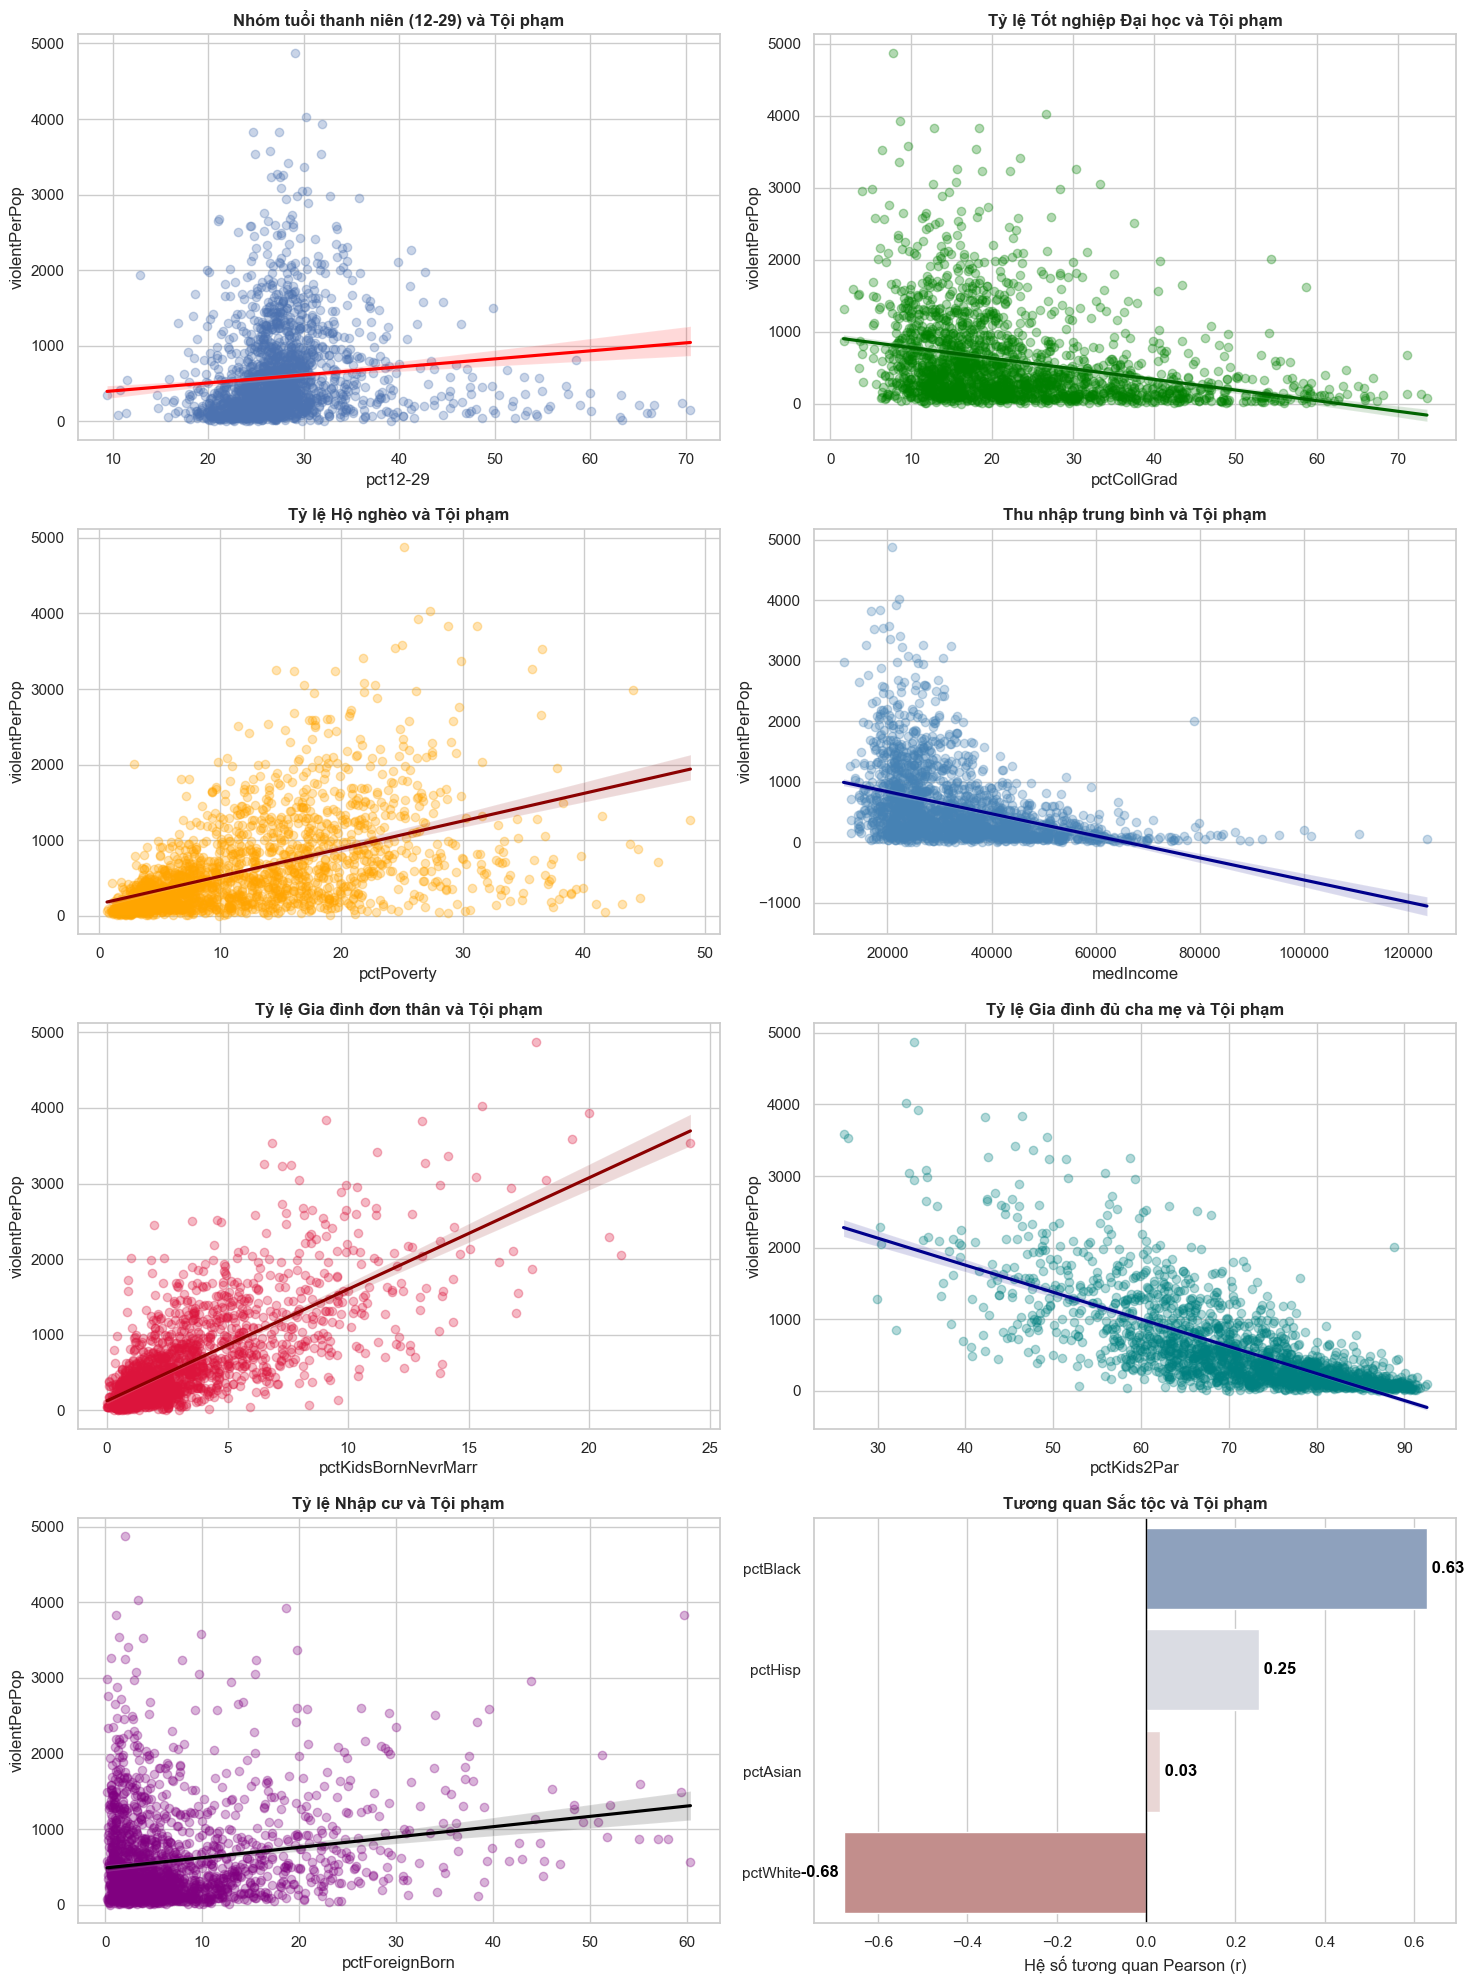

In [30]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

# 1. Tuổi tác
sns.regplot(data=df, x='pct12-29', y=TARGET_VAR, ax=axes[0], scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
axes[0].set_title('Nhóm tuổi thanh niên (12-29) và Tội phạm', fontweight='bold')

# 2. Giáo dục
sns.regplot(data=df, x='pctCollGrad', y=TARGET_VAR, ax=axes[1], color='green', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkgreen'})
axes[1].set_title('Tỷ lệ Tốt nghiệp Đại học và Tội phạm', fontweight='bold')


# 3. Kinh tế - Hộ nghèo
sns.regplot(data=df, x='pctPoverty', y=TARGET_VAR, ax=axes[2], color='orange', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkred'})
axes[2].set_title('Tỷ lệ Hộ nghèo và Tội phạm', fontweight='bold')

# 4. Kinh tế - Thu nhập trung bình
sns.regplot(data=df, x='medIncome', y=TARGET_VAR, ax=axes[3], color='steelblue', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkblue'})
axes[3].set_title('Thu nhập trung bình và Tội phạm', fontweight='bold')


# 5. Cấu trúc gia đình đơn thân
sns.regplot(data=df, x='pctKidsBornNevrMarr', y=TARGET_VAR, ax=axes[4], color='crimson', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkred'})
axes[4].set_title('Tỷ lệ Gia đình đơn thân và Tội phạm', fontweight='bold')

# 6. Cấu trúc gia đình có đủ cha mẹ
sns.regplot(data=df, x='pctKids2Par', y=TARGET_VAR, ax=axes[5], color='teal', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'darkblue'})
axes[5].set_title('Tỷ lệ Gia đình đủ cha mẹ và Tội phạm', fontweight='bold')


# 7. Nhập cư
sns.regplot(data=df, x='pctForeignBorn', y=TARGET_VAR, ax=axes[6], color='purple', scatter_kws={'alpha': 0.3},
            line_kws={'color': 'black'})
axes[6].set_title('Tỷ lệ Nhập cư và Tội phạm', fontweight='bold')

# 8. Sắc tộc
race_vars = ['pctBlack', 'pctWhite', 'pctAsian', 'pctHisp']

# Tính toán tương quan với biến mục tiêu và sắp xếp
race_corr = df[race_vars + [TARGET_VAR]].corr()[[TARGET_VAR]].drop(TARGET_VAR)
race_corr = race_corr.sort_values(by=TARGET_VAR, ascending=False)

# Vẽ biểu đồ
sns.barplot(x=race_corr[TARGET_VAR], y=race_corr.index, ax=axes[7], palette='vlag')

axes[7].set_title('Tương quan Sắc tộc và Tội phạm', fontweight='bold')
axes[7].set_xlabel('Hệ số tương quan Pearson (r)')
axes[7].set_ylabel('')
axes[7].axvline(0, color='black', linewidth=1)

for i, val in enumerate(race_corr[TARGET_VAR]):
    axes[7].text(val, i, f" {val:.2f} ", va='center',
                 ha='left' if val > 0 else 'right', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

**Nhận xét:**
- **Kinh tế** là yếu tố có tác động trực tiếp nhất: tỷ lệ hộ nghèo tương quan dương mạnh với tội phạm.
- **Giáo dục** cho thấy tương quan nghịch rõ rệt, nhấn mạnh vai trò của học vấn.
- **Tuổi tác** (nhóm thanh niên) chỉ có tương quan dương nhẹ.
- **Nhập cư** hầu như không thể hiện mối liên hệ đáng kể.
- **Sắc tộc** xuất hiện hệ số tương quan đáng chú ý, nhưng cần thận trọng khi diễn giải — thường là hệ quả của bất bình đẳng mang tính hệ thống.

### 3.4. Top 15 biến có tương quan mạnh nhất với tội phạm bạo lực

═══════════════════════════════════════════════════════
TOP 15 BIẾN CÓ TƯƠNG QUAN MẠNH NHẤT VỚI TỘI PHẠM BẠO LỰC
(Đã loại trừ các biến thành phần của tội phạm)
═══════════════════════════════════════════════════════
pctKidsBornNevrMarr    0.738089
pctKids2Par           -0.728059
pct2Par               -0.698641
pctWhite              -0.676849
pctKids-4w2Par        -0.658436
pct12-17w2Par         -0.655628
pctBlack               0.628368
pctPubAsst             0.563107
pctWdiv               -0.557787
pctFemDivorc           0.537303
pctAllDivorc           0.536549
pctMaleDivorc          0.510456
pctPersOwnOccup       -0.507330
pctPoverty             0.505349
pctUnemploy            0.483441
Name: violentPerPop, dtype: float64


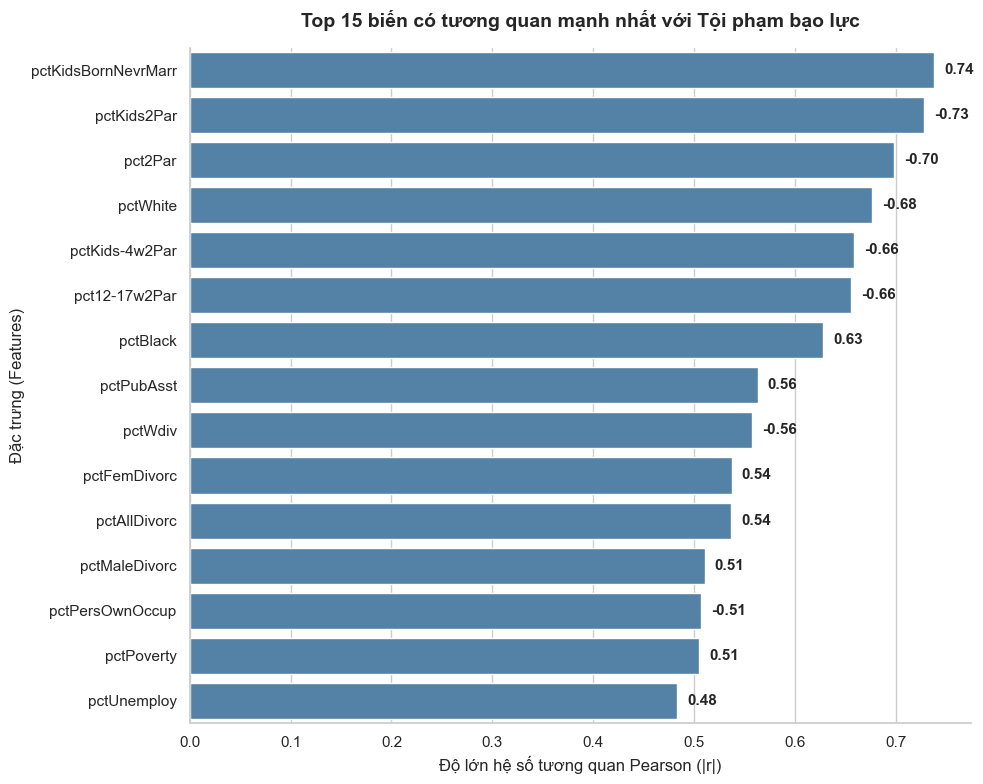

In [31]:
# Tính tương quan của tất cả biến số với biến mục tiêu
numeric_df = df_eda.select_dtypes(include=[np.number])
all_correlations = numeric_df.corr()[[TARGET_VAR]].drop(TARGET_VAR)
all_correlations['abs_corr'] = all_correlations[TARGET_VAR].abs()
correlations_sorted = all_correlations.sort_values(by='abs_corr', ascending=False)

# Lấy Top 15
top_15_vars = correlations_sorted.head(15)

print('═' * 55)
print('TOP 15 BIẾN CÓ TƯƠNG QUAN MẠNH NHẤT VỚI TỘI PHẠM BẠO LỰC')
print('(Đã loại trừ các biến thành phần của tội phạm)')
print('═' * 55)
print(top_15_vars[TARGET_VAR])

# Trực quan hóa
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=top_15_vars['abs_corr'], y=top_15_vars.index, color='steelblue')
plt.title('Top 15 biến có tương quan mạnh nhất với Tội phạm bạo lực',
          fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Độ lớn hệ số tương quan Pearson (|r|)', fontsize=12)
plt.ylabel('Đặc trưng (Features)', fontsize=12)

for i, (index, row) in enumerate(top_15_vars.iterrows()):
    actual_corr = row[TARGET_VAR]
    ax.text(row['abs_corr'] + 0.01, i, f'{actual_corr:.2f}', va='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

**Nhận xét:** Ba nhóm yếu tố chính có ảnh hưởng mạnh nhất:

1. **Cấu trúc gia đình:** Sự rạn nứt gia đình (ly hôn, đơn thân, chưa kết hôn) tương quan thuận rất mạnh. Gia đình có cả cha và mẹ là yếu tố bảo vệ vững chắc nhất.
2. **Điều kiện kinh tế – xã hội:** Nghèo đói, thất nghiệp, nhận trợ cấp ↔ tội phạm cao. Sở hữu nhà, thu nhập đầu tư ↔ tội phạm thấp.
3. **Nhân khẩu học:** Phản ánh sự phân tầng kinh tế – xã hội và rào cản lịch sử hơn là nguyên nhân trực tiếp.

**Kết luận EDA:** Tội phạm bạo lực có nguồn gốc sâu xa từ sự bất ổn của nền tảng gia đình và khó khăn kinh tế – xã hội.

---
# PHẦN 4: OUTLIER HANDLING - Xử lý giá trị ngoại lai

Tỷ lệ tội phạm thường có phân phối lệch phải rất mạnh (nhiều khu vực tỷ lệ thấp, một số ít có tỷ lệ cực kỳ cao). Chúng ta cần:
1. Phân tích phân phối của biến mục tiêu
2. Áp dụng biến đổi logarit (Log1p) cho biến mục tiêu
3. Áp dụng Winsorization cho các biến độc lập

### 4.1. Phân tích phân phối của biến mục tiêu (`violentPerPop`)

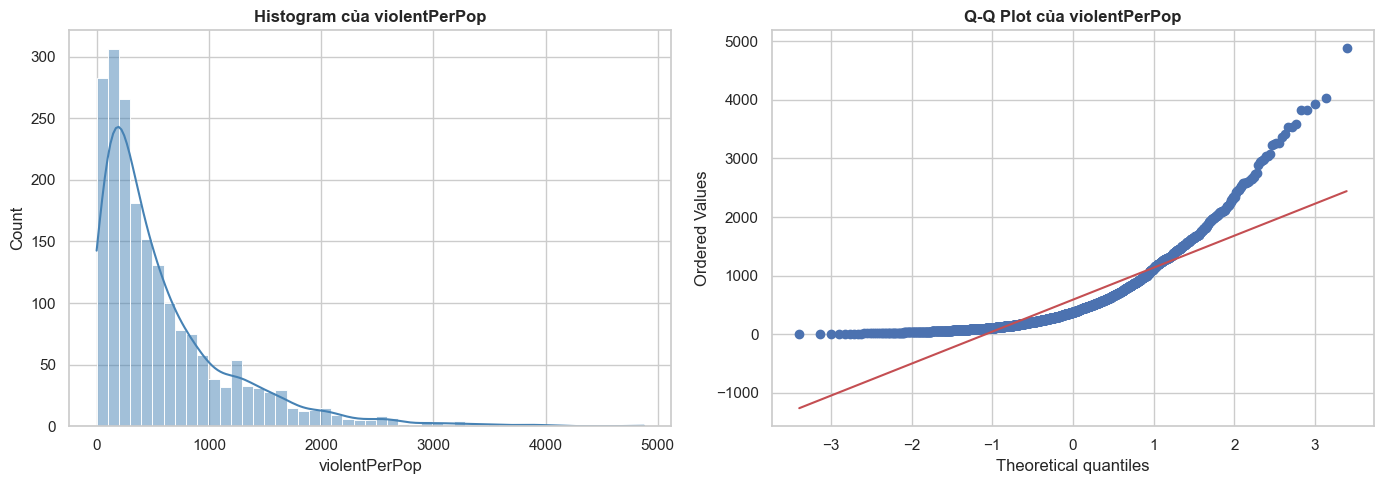

Độ lệch (Skewness):   2.0669
Độ nhọn (Kurtosis):   5.5967
Shapiro-Wilk Test:    Statistic=0.7874, p-value=3.4297e-45
→ Kết luận: Dữ liệu KHÔNG tuân theo phân phối chuẩn (Bác bỏ H0)


In [32]:
plt.figure(figsize=(14, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(df[TARGET_VAR], kde=True, color='steelblue')
plt.title(f'Histogram của {TARGET_VAR}', fontweight='bold')

# Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(df[TARGET_VAR], dist='norm', plot=plt)
plt.title(f'Q-Q Plot của {TARGET_VAR}', fontweight='bold')

plt.tight_layout()
plt.show()

# Kiểm định thống kê
skewness = df[TARGET_VAR].skew()
kurt = df[TARGET_VAR].kurt()
stat, p_value = stats.shapiro(df[TARGET_VAR].sample(min(5000, len(df)), random_state=42))

print(f'Độ lệch (Skewness):   {skewness:.4f}')
print(f'Độ nhọn (Kurtosis):   {kurt:.4f}')
print(f'Shapiro-Wilk Test:    Statistic={stat:.4f}, p-value={p_value:.4e}')

if p_value > 0.05:
    print('→ Kết luận: Dữ liệu CÓ vẻ tuân theo phân phối chuẩn (Không bác bỏ H0)')
else:
    print('→ Kết luận: Dữ liệu KHÔNG tuân theo phân phối chuẩn (Bác bỏ H0)')

### 4.2. Biến đổi Logarit (Log Transformation) cho biến mục tiêu

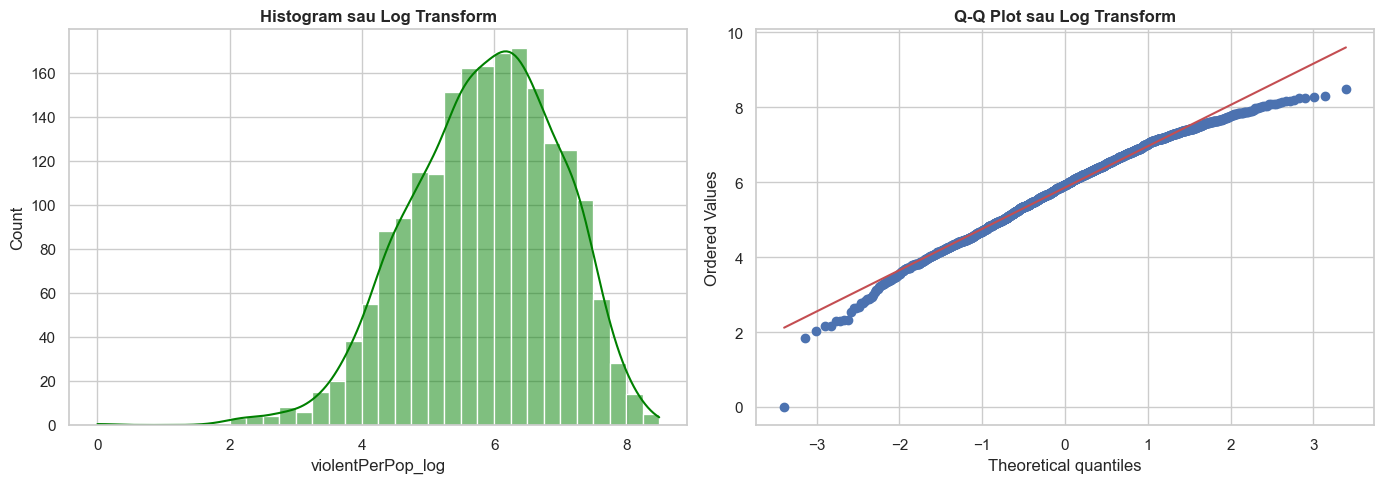

Skewness trước: 2.0669  →  sau: -0.4190
Kurtosis trước: 5.5967  →  sau: 0.1804


In [33]:
# Áp dụng phép biến đổi log1p = log(x + 1) để nén các giá trị cực đoan
df['violentPerPop_log'] = np.log1p(df[TARGET_VAR])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['violentPerPop_log'], kde=True, color='green')
plt.title('Histogram sau Log Transform', fontweight='bold')

plt.subplot(1, 2, 2)
stats.probplot(df['violentPerPop_log'], dist='norm', plot=plt)
plt.title('Q-Q Plot sau Log Transform', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'Skewness trước: {df[TARGET_VAR].skew():.4f}  →  sau: {df["violentPerPop_log"].skew():.4f}')
print(f'Kurtosis trước: {df[TARGET_VAR].kurt():.4f}  →  sau: {df["violentPerPop_log"].kurt():.4f}')

### 4.3. Winsorization cho các biến độc lập (Features)

Áp dụng kỹ thuật **Winsorization** (cắt biên ở ngưỡng percentile 1% và 99%) để giới hạn các giá trị ngoại lai trên biến độc lập trước khi đưa vào mô hình.

In [34]:
def winsorize_features(data, lower_percentile=0.01, upper_percentile=0.99):
    """Cắt biên (clip) ngoại lai cho các biến số, loại trừ biến mục tiêu."""
    df_winsorized = data.copy()
    numeric_cols = df_winsorized.select_dtypes(include=[np.number]).columns
    
    # Loại trừ biến mục tiêu và ID
    exclude = ['fold', 'violentPerPop', 'nonViolPerPop', 'violentPerPop_log']
    cols_to_winsorize = [c for c in numeric_cols if c not in exclude]
    
    for col in cols_to_winsorize:
        lower = df_winsorized[col].quantile(lower_percentile)
        upper = df_winsorized[col].quantile(upper_percentile)
        df_winsorized[col] = np.clip(df_winsorized[col], lower, upper)
        
    return df_winsorized

df_treated = winsorize_features(df)
print('Đã hoàn tất Winsorization cho các biến độc lập (percentile 1% – 99%).')

Đã hoàn tất Winsorization cho các biến độc lập (percentile 1% – 99%).


---
# PHẦN 5: FEATURE ENGINEERING - Kỹ thuật đặc trưng

Giai đoạn chuẩn bị dữ liệu cho mô hình:
1. Loại bỏ các biến định danh (communityname, State, fold, ...)
2. Loại bỏ các biến thành phần tội phạm (để tránh data leakage)
3. Chuẩn hóa đặc trưng (StandardScaler)
4. Chia tập Train/Test (80/20)

In [35]:
# CHUẨN BỊ DỮ LIỆU CHO MÔ HÌNH
# ═══════════════════════════════════════════════════════

# Các cột cần loại bỏ: ID, metadata, biến mục tiêu, các biến thành phần tội phạm
cols_to_drop = [
    'communityname', 'State', 'countyCode', 'communityCode', 'fold',
    'violentPerPop', 'violentPerPop_log', 'nonViolPerPop',
    'murders', 'murdPerPop', 'rapes', 'rapesPerPop', 'robberies', 'robbbPerPop',
    'assaults', 'assaultPerPop', 'burglaries', 'burglPerPop',
    'larcenies', 'larcPerPop', 'autoTheft', 'autoTheftPerPop',
    'arsons', 'arsonsPerPop'
]

# --- Mô hình trên biến gốc (chưa xử lý outlier) ---
X_raw = df.select_dtypes(include=[np.number]).drop(
    columns=[c for c in cols_to_drop if c in df.columns], errors='ignore'
)
y_raw = df[TARGET_VAR]

# --- Mô hình trên biến đã xử lý outlier (Log target + Winsorized features) ---
X_treated = df_treated.select_dtypes(include=[np.number]).drop(
    columns=[c for c in cols_to_drop if c in df_treated.columns], errors='ignore'
)
y_treated = df_treated['violentPerPop_log']  # Biến mục tiêu đã log-transform

# Chia Train/Test (80/20)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)
X_train_treated, X_test_treated, y_train_treated, y_test_treated = train_test_split(
    X_treated, y_treated, test_size=0.2, random_state=42
)

# Chuẩn hóa StandardScaler
scaler_raw = StandardScaler()
X_train_raw_sc = scaler_raw.fit_transform(X_train_raw)
X_test_raw_sc = scaler_raw.transform(X_test_raw)

scaler_treated = StandardScaler()
X_train_treated_sc = scaler_treated.fit_transform(X_train_treated)
X_test_treated_sc = scaler_treated.transform(X_test_treated)

print(f'Số đặc trưng (features): {X_raw.shape[1]}')
print(f'Tập Train: {X_train_raw.shape[0]} mẫu  |  Tập Test: {X_test_raw.shape[0]} mẫu')
print(f'Đã hoàn tất chuẩn bị dữ liệu!')

Số đặc trưng (features): 102
Tập Train: 1595 mẫu  |  Tập Test: 399 mẫu
Đã hoàn tất chuẩn bị dữ liệu!


---
# PHẦN 6: MODELLING - Xây dựng Mô hình

Tiến hành huấn luyện 4 mô hình hồi quy:
1. **Linear Regression** - Hồi quy tuyến tính cổ điển
2. **Polynomial Regression (Degree 2)** - Hồi quy đa thức bậc 2
3. **Random Forest** - Hồi quy rừng ngẫu nhiên
4. **Gradient Boosting** - Tăng cường gradient

Mỗi mô hình được huấn luyện trên 2 phiên bản dữ liệu:
- **Dữ liệu gốc:** Chưa xử lý ngoại lai
- **Dữ liệu đã xử lý:** Log-transformed target + Winsorized features

### 6.1. Huấn luyện mô hình trên dữ liệu gốc (chưa xử lý ngoại lai)

In [36]:
# Định nghĩa các mô hình
models_raw = {
    'Linear Regression': LinearRegression(),
    'Polynomial Regression (Degree 2)': make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False), LinearRegression()),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results_raw = []
for name, model in models_raw.items():
    model.fit(X_train_raw_sc, y_train_raw)
    y_pred = model.predict(X_test_raw_sc)
    
    r2 = r2_score(y_test_raw, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_raw, y_pred))
    results_raw.append({'Mô hình': name, 'R² Score': round(r2, 4), 'RMSE': round(rmse, 2)})

results_raw_df = pd.DataFrame(results_raw).sort_values(by='R² Score', ascending=False)
print('Kết quả trên DỮ LIỆU GỐC:')
display(results_raw_df)

Kết quả trên DỮ LIỆU GỐC:


,Mô hình,R² Score,RMSE
3,Gradient Boosting,0.6300,358.86
2,Random Forest,0.6171,365.05
0,Linear Regression,0.5955,375.21
1,Polynomial Regression (Degree 2),-8.2019,1789.53


### 6.2. Huấn luyện mô hình trên dữ liệu ĐÃ XỬ LÝ NGOẠI LAI

In [37]:
# Định nghĩa các mô hình (khởi tạo mới)
models_treated = {
    'Linear Regression': LinearRegression(),
    'Polynomial Regression (Degree 2)': make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False), LinearRegression()),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

results_treated = {}
fitted_models_treated = {}

for name, model in models_treated.items():
    model.fit(X_train_treated_sc, y_train_treated)
    preds = model.predict(X_test_treated_sc)
    
    rmse = np.sqrt(mean_squared_error(y_test_treated, preds))
    r2 = r2_score(y_test_treated, preds)
    results_treated[name] = {'R²': round(r2, 4), 'RMSE (Log Scale)': round(rmse, 4)}
    fitted_models_treated[name] = model

results_treated_df = pd.DataFrame(results_treated).T
print('Kết quả trên DỮ LIỆU ĐÃ XỬ LÝ (Log target + Winsorized features):')
display(results_treated_df)

Kết quả trên DỮ LIỆU ĐÃ XỬ LÝ (Log target + Winsorized features):


,R²,RMSE (Log Scale)
Linear Regression,0.5957,0.7203
Polynomial Regression (Degree 2),-1.1188,1.6489
Random Forest,0.6152,0.7027
Gradient Boosting,0.6284,0.6905


---
# PHẦN 7: So sánh và đánh giá theo mô hình Gradient Boosting

Vì hệ số R² của mô hình hồi quy tuyến tính chưa đạt kết quả như mong đợi, nhóm tiến hành đánh giá bổ sung bằng mô hình Gradient Boosting nhằm so sánh khả năng dự đoán và kiểm tra xem liệu mô hình phi tuyến có thể mô tả dữ liệu hiệu quả hơn hay không.

Giai đoạn đánh giá bao gồm:
1. **So sánh trực quan:** Thực tế vs. Dự đoán (mô hình tốt nhất)
2. **Feature Importance:** Top 10 yếu tố đặc trưng quyết định
3. **Phân tích phần dư (Residual Analysis):** Kiểm tra giả định hồi quy tuyến tính

### 7.1. So sánh trực quan hóa: Thực tế vs. Dự đoán & Feature Importance (Dữ liệu gốc)

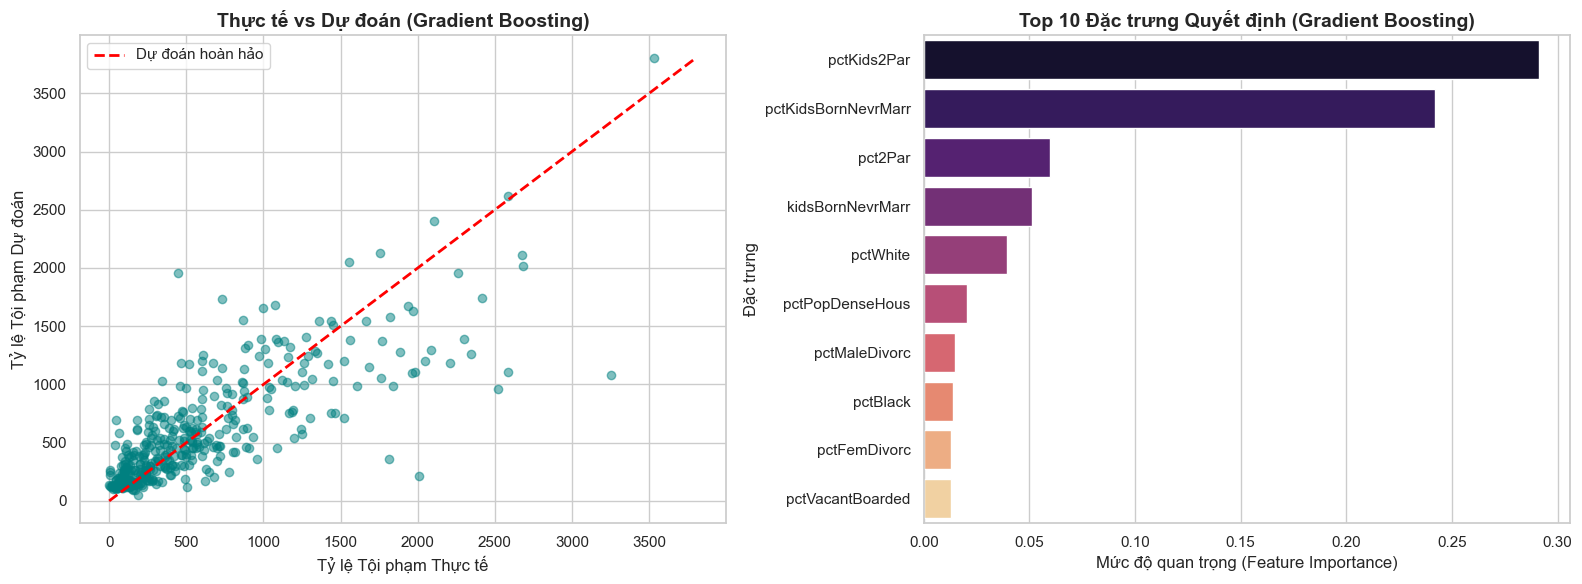

In [38]:
# Trích xuất mô hình tốt nhất trên dữ liệu gốc
best_model_name = results_raw_df.iloc[0]['Mô hình']
best_model = models_raw[best_model_name]

y_pred_best = best_model.predict(X_test_raw_sc)
y_pred_best = np.clip(y_pred_best, 0, None)  # Tỷ lệ tội phạm không thể âm

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Biểu đồ 1: Thực tế vs Dự đoán ──
axes[0].scatter(y_test_raw, y_pred_best, alpha=0.5, color='teal')
max_val = max(y_test_raw.max(), y_pred_best.max())
axes[0].plot([0, max_val], [0, max_val], color='red', linestyle='--', lw=2, label='Dự đoán hoàn hảo')
axes[0].set_title(f'Thực tế vs Dự đoán ({best_model_name})', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Tỷ lệ Tội phạm Thực tế')
axes[0].set_ylabel('Tỷ lệ Tội phạm Dự đoán')
axes[0].legend()

# ── Biểu đồ 2: Top 10 Feature Importance ──
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X_raw.columns)
    top_10 = importances.sort_values(ascending=False).head(10)
    sns.barplot(x=top_10.values, y=top_10.index, ax=axes[1], palette='magma')
    axes[1].set_title(f'Top 10 Đặc trưng Quyết định ({best_model_name})', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('Mức độ quan trọng (Feature Importance)')
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(best_model.coef_, index=X_raw.columns)
    top_10 = coefs.abs().sort_values(ascending=False).head(10)
    sns.barplot(x=top_10.values, y=top_10.index, ax=axes[1], palette='viridis')
    axes[1].set_title(f'Top 10 Trọng số lớn nhất ({best_model_name})', fontweight='bold', fontsize=14)
    axes[1].set_xlabel('|Coefficients|')
axes[1].set_ylabel('Đặc trưng')

plt.tight_layout()
plt.show()

**Nhận xét mô hình Gradient Boosting (dựa trên dữ liệu gốc):**

1. **Khả năng dự báo:** Hoạt động tốt ở ngưỡng thấp và trung bình (< 1000), nhưng dự đoán thấp hơn thực tế (underpredict) ở các điểm nóng tội phạm (> 1500).

2. **Yếu tố quyết định:** Cấu trúc gia đình là yếu tố cốt lõi - 2 biến `pctKids2Par` và `pctKidsBornNevrMarr` có feature importance áp đảo (0.25 - 0.30).

3. **Yếu tố thứ cấp:** Nhân khẩu học (pctWhite, pctBlack), tình trạng nhà ở (pctPopDenseHous, pctVacantBoarded), sự rạn nứt hôn nhân (pctMaleDivorc, pctFemDivorc).

### 7.2. Phân tích Phần dư (Residual Analysis) - Kiểm tra giả định Hồi quy tuyến tính

Phân tích phần dư trên mô hình Linear Regression (dữ liệu đã xử lý outlier) để kiểm tra:
- **Homoscedasticity:** Phần dư phân tán ngẫu nhiên quanh trục 0
- **Normality:** Phần dư có phân phối chuẩn

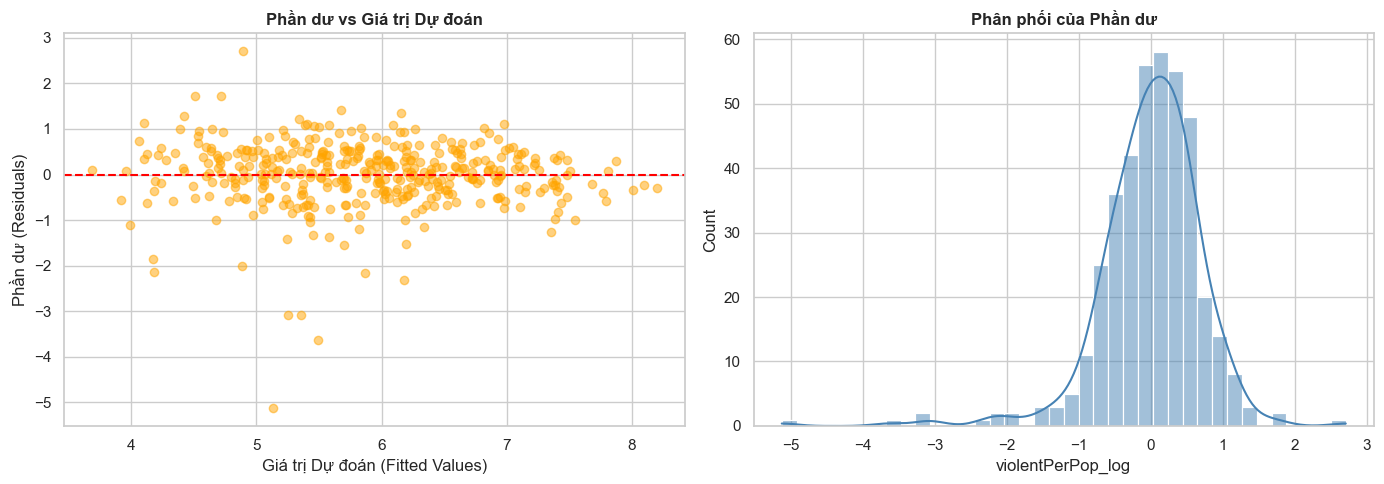

Mean Residual:    -0.002570
Std Residual:     0.721165
Skewness:         -1.6970
Kurtosis:         9.3390


In [39]:
# Lấy mô hình Linear Regression đã fit trên dữ liệu treated
lr_model = fitted_models_treated['Linear Regression']
lr_preds = lr_model.predict(X_test_treated_sc)
residuals = y_test_treated - lr_preds

plt.figure(figsize=(14, 5))

# ── Residuals vs Fitted ──
plt.subplot(1, 2, 1)
plt.scatter(lr_preds, residuals, alpha=0.5, color='orange')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Giá trị Dự đoán (Fitted Values)')
plt.ylabel('Phần dư (Residuals)')
plt.title('Phần dư vs Giá trị Dự đoán', fontweight='bold')

# ── Histogram of Residuals ──
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='steelblue')
plt.title('Phân phối của Phần dư', fontweight='bold')

plt.tight_layout()
plt.show()

# Thống kê phần dư
print(f'Mean Residual:    {residuals.mean():.6f}')
print(f'Std Residual:     {residuals.std():.6f}')
print(f'Skewness:         {residuals.skew():.4f}')
print(f'Kurtosis:         {residuals.kurt():.4f}')

---
# PHẦN 8: Tổng kết

---

### 8.1. Tóm tắt kết quả

| Giai đoạn | Kết quả chính |
|-----------|---------------|
| **Data Cleaning** | Từ 2.215 dòng × 147 cột → ~1.994 dòng × 123 cột sau khi loại bỏ 24 cột thiếu >50%, xóa hàng thiếu biến mục tiêu, điền median |
| **EDA** | D.C. và Maryland dẫn đầu về tỷ lệ tội phạm. Cấu trúc gia đình, nghèo đói, thất nghiệp là các yếu tố tương quan mạnh nhất |
| **Outlier Handling** | Log1p transform giảm skewness đáng kể. Winsorization (1%-99%) cho features |
| **Modelling** | Gradient Boosting cho R² cao nhất trên cả dữ liệu gốc và đã xử lý |
| **Residual Analysis** | Log transform cải thiện phương sai sai số. Mô hình phi tuyến (RF, GB) phù hợp hơn Linear Regression |

### 8.2. Phát hiện chính

1. **Phân tích Phân phối:** Dữ liệu `violentPerPop` ban đầu bị lệch phải rất mạnh với nhiều ngoại lai cực đoan. Kiểm định Shapiro-Wilk xác nhận dữ liệu không tuân theo phân phối chuẩn.

2. **Xử lý Ngoại lai:** Biến đổi `log1p` cho biến mục tiêu kết hợp `winsorization` cho biến độc lập giúp bảo vệ mô hình khỏi nhiễu ngoại lai.

3. **Hiệu suất Mô hình:** Dự đoán trên thang đo logarit giúp ổn định phương sai và cải thiện R² nhờ đưa phân phối biến mục tiêu gần chuẩn hơn.

4. **Phân tích Phần dư:** Nếu đồ thị phần dư vẫn có dạng hình phễu hoặc đường cong, cho thấy tồn tại hiện tượng phương sai thay đổi (heteroscedasticity) hoặc quan hệ phi tuyến - đây cũng là lý do có thêm mô hình phi tuyến (Random Forest, Gradient Boosting).

### 8.3. Kết luận

Mô hình **Gradient Boosting** cho thấy tỷ lệ tội phạm bạo lực được quyết định chủ yếu bởi:
- **Cấu trúc gia đình** (biến `pctKids2Par`, `pctKidsBornNevrMarr` có feature importance áp đảo)
- **Điều kiện kinh tế - xã hội** (nghèo đói, thất nghiệp, nhà ở)
- **Nhân khẩu học** (phản ánh bất bình đẳng hệ thống)

Tội phạm bạo lực có nguồn gốc sâu xa từ sự bất ổn định của nền tảng gia đình và những khó khăn về kinh tế - xã hội, đòi hỏi giải pháp can thiệp đa chiều từ chính sách công.

### 8.4. Hạn chế và hướng phát triển

- Mô hình vẫn **underpredict** ở các điểm nóng tội phạm (tỷ lệ > 1500), cần tinh chỉnh thêm.
- Có thể thử **Cross-validation** và **Hyperparameter tuning** (GridSearchCV) để tối ưu.
- Bổ sung thêm dữ liệu thời gian (time-series) để phân tích xu hướng tội phạm.